# 01. 데이터 확인

`document_고무서/dataset/`에 만든 쿼리 노이즈 강건성 데이터셋을 점검한다.
청크 128개 x 노이즈 8변형 = 1,024쌍이 의도대로 만들어졌는지, 카테고리/길이 분포가
한쪽으로 쏠리지 않았는지 표와 그래프로 확인한다.

산출물: `document_고무서/output/embedding-finetune/01_data_check/`

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

DATASET_DIR = Path("../dataset")
OUTPUT_DIR = Path("../output/embedding-finetune/01_data_check")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

full_df = pd.read_csv(DATASET_DIR / "query_noise_robustness_dataset.csv")
train_df = pd.read_csv(DATASET_DIR / "train_pairs.csv")
eval_df = pd.read_csv(DATASET_DIR / "eval_pairs.csv")

print(f"전체: {len(full_df)}행 / train: {len(train_df)}행 / eval: {len(eval_df)}행")

전체: 1024행 / train: 816행 / eval: 208행


## 1. 기본 통계

In [2]:
summary_table = pd.DataFrame(
    [
        {"항목": "전체 쌍(clean+noisy)", "값": len(full_df)},
        {"항목": "고유 청크 수", "값": full_df["chunk_id"].nunique()},
        {"항목": "train 쌍", "값": len(train_df)},
        {"항목": "train 고유 청크", "값": train_df["id"].nunique()},
        {"항목": "eval 쌍", "값": len(eval_df)},
        {"항목": "eval 고유 청크", "값": eval_df["id"].nunique()},
    ]
)
summary_table.to_csv(OUTPUT_DIR / "summary_table.csv", index=False)
summary_table

,항목,값
0,전체 쌍(clean+noisy),1024
1,고유 청크 수,128
2,train 쌍,816
3,train 고유 청크,102
4,eval 쌍,208
5,eval 고유 청크,26


## 2. 노이즈 카테고리 분포

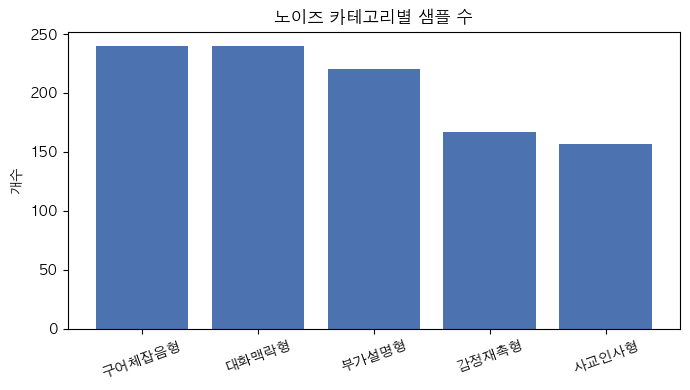

,noise_category,count
0,구어체잡음형,240
1,대화맥락형,240
2,부가설명형,220
3,감정재촉형,167
4,사교인사형,157


In [3]:
category_counts = full_df["noise_category"].value_counts().rename_axis("noise_category").reset_index(name="count")
category_counts.to_csv(OUTPUT_DIR / "category_distribution.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(category_counts["noise_category"], category_counts["count"], color="#4C72B0")
ax.set_title("노이즈 카테고리별 샘플 수")
ax.set_ylabel("개수")
plt.xticks(rotation=20)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "category_distribution.png", dpi=150)
plt.show()

category_counts

## 3. source_type 분포 (train vs eval)

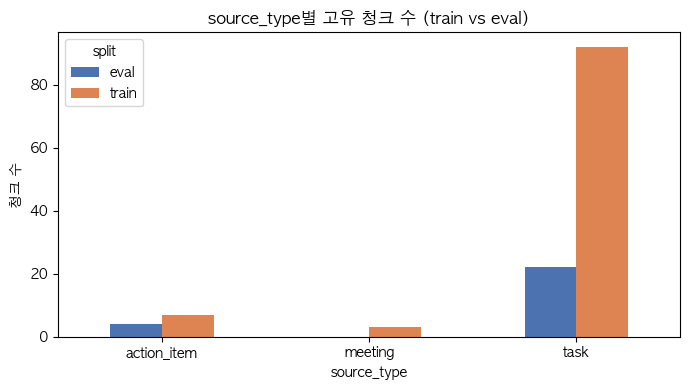

split,eval,train
source_type,,
action_item,4,7
meeting,0,3
task,22,92


In [4]:
source_split = (
    pd.concat([train_df.assign(split="train"), eval_df.assign(split="eval")])
    .drop_duplicates(subset=["id", "split"])
    .groupby(["source_type", "split"])
    .size()
    .unstack(fill_value=0)
)
source_split.to_csv(OUTPUT_DIR / "source_type_split.csv")

ax = source_split.plot(kind="bar", figsize=(7, 4), color=["#4C72B0", "#DD8452"])
ax.set_title("source_type별 고유 청크 수 (train vs eval)")
ax.set_ylabel("청크 수")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "source_type_split.png", dpi=150)
plt.show()

source_split

## 4. 질문 길이 분포 (clean vs noisy)

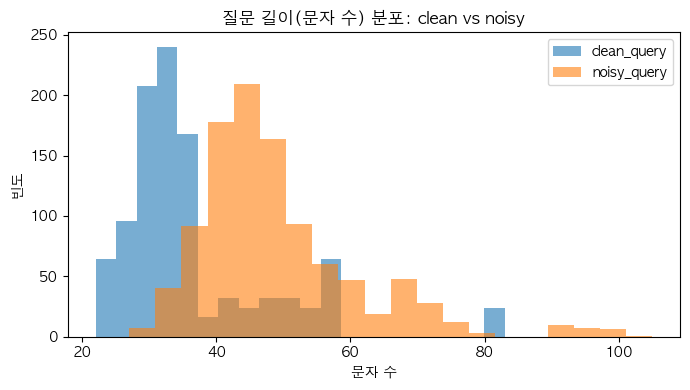

,clean_len,noisy_len
count,1024.0,1024.0
mean,36.6,49.1
std,11.3,12.2
min,22.0,27.0
25%,30.0,41.0
50%,33.0,46.0
75%,37.0,54.0
max,83.0,105.0


In [5]:
full_df["clean_len"] = full_df["clean_query"].str.len()
full_df["noisy_len"] = full_df["noisy_query"].str.len()

length_stats = full_df[["clean_len", "noisy_len"]].describe().round(1)
length_stats.to_csv(OUTPUT_DIR / "length_stats.csv")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(full_df["clean_len"], bins=20, alpha=0.6, label="clean_query")
ax.hist(full_df["noisy_len"], bins=20, alpha=0.6, label="noisy_query")
ax.set_title("질문 길이(문자 수) 분포: clean vs noisy")
ax.set_xlabel("문자 수")
ax.set_ylabel("빈도")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "length_distribution.png", dpi=150)
plt.show()

length_stats

## 5. 샘플 확인

In [6]:
sample = full_df.sample(5, random_state=0)[["source_type", "noise_category", "clean_query", "noisy_query"]]
sample.to_csv(OUTPUT_DIR / "sample_rows.csv", index=False)
sample

,source_type,noise_category,clean_query,noisy_query
927,task,감정재촉형,팀원별 업무량 차트/과부하 표시 구현 업무는 어떤 내용이야?,팀원별 업무량 차트/과부하 표시 구현 업무는 어떤 내용이야? 급한데 빨리 부탁해
27,task,구어체잡음형,프로젝트 대시보드 기본 집계를 제공한다 업무는 어떤 내용이야?,프로젝트 대시보드 기본 집계를 제공한다 업무는 어떤 내용이야? ㅋㅋ 그냥 확인차
77,task,감정재촉형,ML 모델링 파이프라인을 지원한다 업무는 어떤 내용이야?,ML 모델링 파이프라인을 지원한다 업무는 어떤 내용이야? 좀 답답해서 그러는데
609,task,부가설명형,업무 상세/대시보드 위험도 표시 구현 업무는 어떤 내용이야?,업무 상세/대시보드 위험도 표시 구현 업무는 어떤 내용이야? (그냥 확인차 물어봄)
320,task,감정재촉형,학습/평가 노트북 및 산출물 정리 업무는 어떤 내용이야?,학습/평가 노트북 및 산출물 정리 업무는 어떤 내용이야? 좀 답답해서 그러는데


## 확인 결과

- 카테고리별 표본 수가 대체로 고르게 분포되어 있는지(`category_distribution.png`),
  clean/noisy 길이 분포가 겹치는지(`length_distribution.png`)를 위 그래프로 확인한다.
- 다음 단계(`02_preprocessing.ipynb`)에서 train/eval 청크 중복(leakage) 여부와
  코퍼스 중복 제거를 진행한다.